In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

pd.options.display.float_format = '{:,.2f}'.format


def limpar_valor(valor):
    if pd.isna(valor): return 0
    if isinstance(valor, (int, float)): return valor
    valor = str(valor).replace('€', '').strip()
    if 'M' in valor: return float(valor.replace('M', '')) * 1_000_000
    if 'K' in valor: return float(valor.replace('K', '')) * 1_000
    return float(valor)

def limpar_idade(valor):
    if pd.isna(valor): return 0
    valor = str(valor)
    if '(' in valor: return int(valor.split('(')[-1].replace(')', ''))
    return 0

arquivos = [
    ('Bundesliga', 'jogadores/sofascore_bundesliga_geral_final_valor_de_mercado_24_25.csv'),
    ('Premier League', 'jogadores/sofascore_premier_league_geral_final_valor_de_mercado_24_25.csv'),
    ('La Liga', 'jogadores/sofascore_laliga_geral_final_valor_de_mercado_24_25.csv'),
    ('Serie A', 'jogadores/sofascore_italiano_geral_final_valor_de_mercado_24_25.csv')
]

dfs = []
for nome_liga, arquivo in arquivos:
    try:
        d = pd.read_csv(arquivo)
        d['Liga'] = nome_liga
        # Limpezas essenciais
        d['Valor_Numerico'] = d['Valor de mercado'].apply(limpar_valor)
        d['Idade_Limpa'] = d['Idade'].apply(limpar_idade)
        dfs.append(d)
    except:
        print(f"Erro ao ler {arquivo}")

df_geral = pd.concat(dfs, ignore_index=True)

print(f"Base Geral carregada com {len(df_geral)} jogadores das 4 ligas!")

Base Geral carregada com 1290 jogadores das 4 ligas!


C:\Users\felip\AppData\Local\Temp\ipykernel_11108\2019376102.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Liga', y='Valor_Numerico', data=df_geral, showfliers=False, palette='viridis')


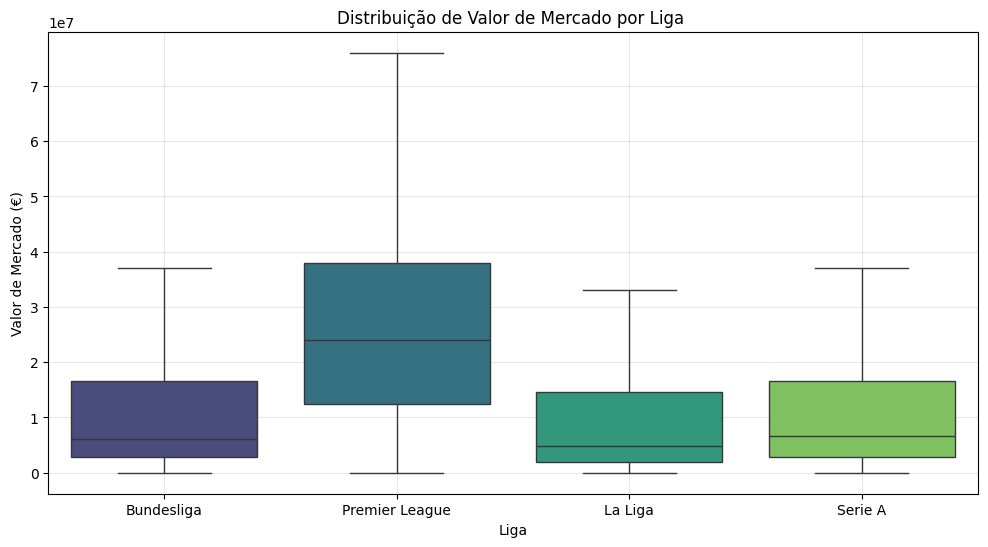

In [2]:
# 1. Boxplot: Comparação de Preços (Quem é mais caro?)
plt.figure(figsize=(12, 6))
sns.boxplot(x='Liga', y='Valor_Numerico', data=df_geral, showfliers=False, palette='viridis')
plt.title('Distribuição de Valor de Mercado por Liga ')
plt.ylabel('Valor de Mercado (€)')
plt.grid(True, alpha=0.3)
plt.show()

# 2. Scatter: Performance x Preço (A Inflação Visual)
# Quem paga mais por uma nota 7.0?
fig = px.scatter(df_geral, 
                 x='Média das notas Sofascore', 
                 y='Valor_Numerico', 
                 color='Liga',
                 hover_data=['Nome', 'Time'],
                 opacity=0.6,
                 title='Inflação do Futebol: O custo da nota SofaScore em cada país',
                 labels={'Valor_Numerico': 'Preço (€)', 'Média das notas Sofascore': 'Nota Média'})
fig.show()

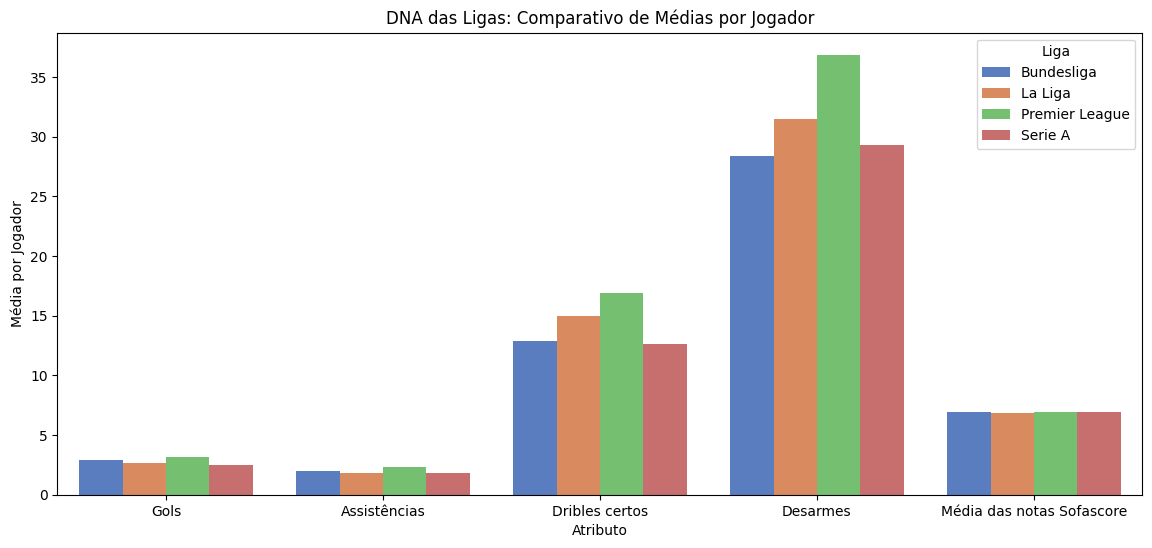

,Liga,Gols,Assistências,Dribles certos,Desarmes,Média das notas Sofascore
0,Bundesliga,2.88,2.01,12.87,28.43,6.93
1,La Liga,2.63,1.79,14.96,31.50,6.89
2,Premier League,3.15,2.34,16.93,36.88,6.94
3,Serie A,2.49,1.83,12.65,29.29,6.89


In [3]:
# Selecionamos métricas táticas importantes
# Certifique-se que essas colunas existem e são numéricas (pode precisar de limpeza se tiverem %)
metricas = ['Gols', 'Assistências', 'Dribles certos', 'Desarmes', 'Média das notas Sofascore']

# Agrupa por Liga e tira a média
dna_ligas = df_geral.groupby('Liga')[metricas].mean().reset_index()

# Derrete a tabela para formato longo (necessário para o Seaborn/Plotly agrupar barras)
dna_long = pd.melt(dna_ligas, id_vars='Liga', var_name='Atributo', value_name='Media_Por_Jogador')

plt.figure(figsize=(14, 6))
sns.barplot(x='Atributo', y='Media_Por_Jogador', hue='Liga', data=dna_long, palette='muted')
plt.title('DNA das Ligas: Comparativo de Médias por Jogador')
plt.ylabel('Média por Jogador')
plt.xticks(rotation=0)
plt.legend(title='Liga')
plt.show()

display(dna_ligas)

C:\Users\felip\AppData\Local\Temp\ipykernel_11108\1432214445.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




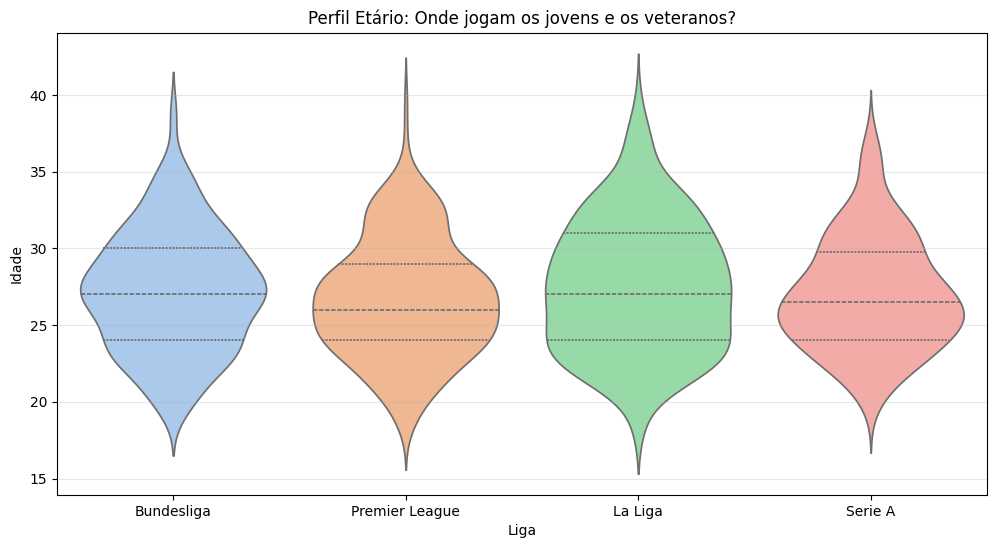

Média de Idade por Liga:
Liga
Premier League   26.73
Serie A          27.02
Bundesliga       27.21
La Liga          27.54
Name: Idade_Limpa, dtype: float64


In [4]:
plt.figure(figsize=(12, 6))

# Violin Plot é melhor que histograma para comparar distribuições
sns.violinplot(x='Liga', y='Idade_Limpa', data=df_geral, palette='pastel', inner='quartile')

plt.title('Perfil Etário: Onde jogam os jovens e os veteranos?')
plt.ylabel('Idade')
plt.grid(axis='y', alpha=0.3)
plt.show()

# Estatística descritiva rápida
print("Média de Idade por Liga:")
print(df_geral.groupby('Liga')['Idade_Limpa'].mean().sort_values())

In [5]:
def montar_selecao_europa(df):
    print("🏆 SELEÇÃO IDEAL DAS 4 LIGAS (Baseado em SofaScore) 🏆")
    print("-" * 50)
    
    
    # Goleiro (1)
    goleiro = df[df['Posição'].str.contains('Goalkeeper|Goleiro', case=False, na=False)] \
                .sort_values('Média das notas Sofascore', ascending=False).head(1)
    
    # Defensores (4)
    defesa = df[df['Posição'].str.contains('Defender|Zagueiro|Lateral', case=False, na=False)] \
                .sort_values('Média das notas Sofascore', ascending=False).head(4)
    
    # Meias (3)
    meio = df[df['Posição'].str.contains('Midfielder|Meia|Volante', case=False, na=False)] \
                .sort_values('Média das notas Sofascore', ascending=False).head(3)
    
    # Atacantes (3)
    ataque = df[df['Posição'].str.contains('Forward|Atacante|Ponta', case=False, na=False)] \
                .sort_values('Média das notas Sofascore', ascending=False).head(3)
    
    selecao = pd.concat([goleiro, defesa, meio, ataque])
    
    cols_show = ['Posição', 'Nome', 'Time', 'Liga', 'Média das notas Sofascore', 'Valor_Numerico']
    display(selecao[cols_show])
    
    custo_total = selecao['Valor_Numerico'].sum()
    print(f"\n💰 Custo total do Dream Team: € {custo_total:,.0f}")

# Executa
montar_selecao_europa(df_geral)

🏆 SELEÇÃO IDEAL DAS 4 LIGAS (Baseado em SofaScore) 🏆
--------------------------------------------------


,Posição,Nome,Time,Liga,Média das notas Sofascore,Valor_Numerico
307,Goleiro,Mark Flekken,Bayer 04 Leverkusen,Premier League,7.40,"10,700,000.00"
10,Defender,Maximilian Mittelstädt,VfB Stuttgart,Bundesliga,7.37,"22,000,000.00"
309,Defender,Joško Gvardiol,Manchester City,Premier League,7.37,"69,000,000.00"
12,Defender,Dayot Upamecano,FC Bayern München,Bundesliga,7.37,"55,000,000.00"
316,Defender,James Tarkowski,Everton,Premier League,7.30,0.00
1,Midfielder,Joshua Kimmich,FC Bayern München,Bundesliga,7.91,"49,000,000.00"
2,Midfielder,Michael Olise,FC Bayern München,Bundesliga,7.91,"125,000,000.00"
616,Midfielder,Raphinha,Barcelona,La Liga,7.80,"81,000,000.00"
0,Forward,Omar Marmoush,Manchester City,Bundesliga,8.16,"82,000,000.00"
3,Forward,Harry Kane,FC Bayern München,Bundesliga,7.73,"81,000,000.00"



💰 Custo total do Dream Team: € 765,700,000


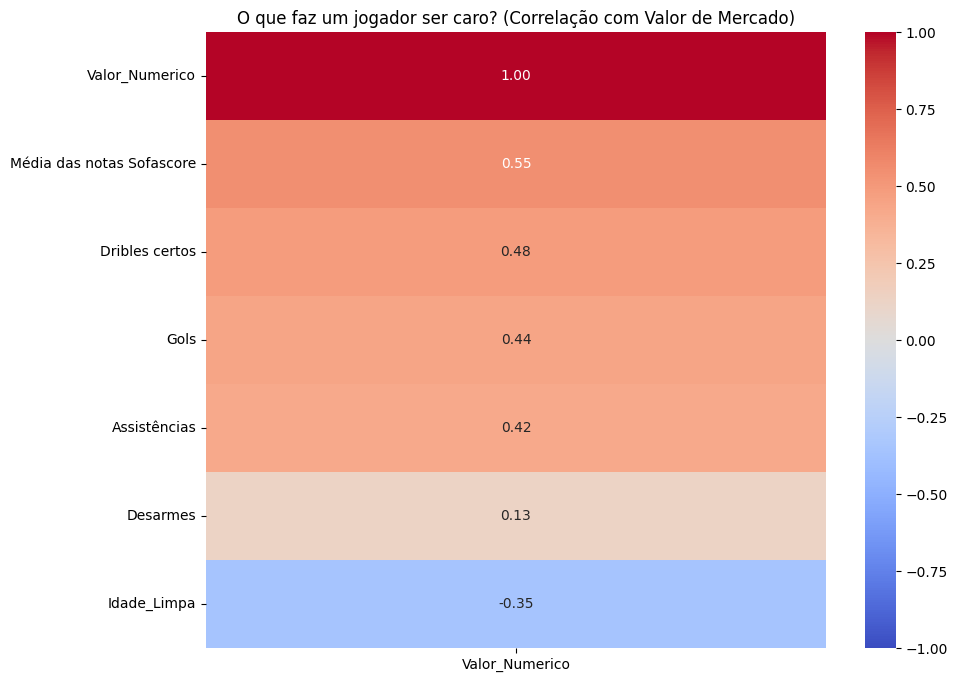

INTERPRETAÇÃO RÁPIDA:
- Idade: -0.35 (Se negativo: Quanto mais velho, mais barato)
- Performance (SofaScore): 0.55 (Quanto a nota impacta no preço)


In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

colunas_analise = [
    'Valor_Numerico', 
    'Idade_Limpa', 
    'Média das notas Sofascore', 
    'Gols', 
    'Assistências', 
    'Dribles certos', 
    'Desarmes',
    'Passe_Numerico'
]

colunas_existentes = [c for c in colunas_analise if c in df_geral.columns]

correlacao = df_geral[colunas_existentes].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlacao[['Valor_Numerico']].sort_values(by='Valor_Numerico', ascending=False), 
            annot=True, 
            cmap='coolwarm', 
            vmin=-1, vmax=1, 
            fmt=".2f")

plt.title('O que faz um jogador ser caro? (Correlação com Valor de Mercado)')
plt.show()

print("INTERPRETAÇÃO RÁPIDA:")
corr_idade = correlacao.loc['Idade_Limpa', 'Valor_Numerico']
corr_sofa = correlacao.loc['Média das notas Sofascore', 'Valor_Numerico']

print(f"- Idade: {corr_idade:.2f} (Se negativo: Quanto mais velho, mais barato)")
print(f"- Performance (SofaScore): {corr_sofa:.2f} (Quanto a nota impacta no preço)")

Analisando 135 jogadores de Elite (Valor > € 41.0M)


<Figure size 1200x600 with 0 Axes>

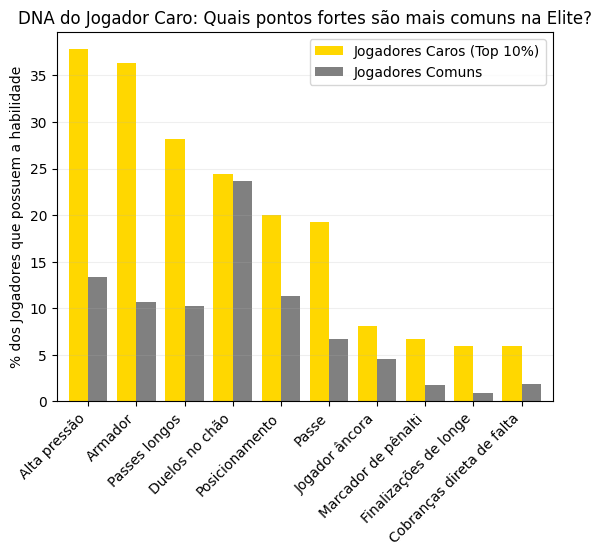

TOP 5 HABILIDADES QUE VALORIZAM O JOGADOR:


,Frequencia_Elite (%),Frequencia_Comum (%),Diferenca
Alta pressão,37.78,13.33,24.44
Armador,36.30,10.65,25.65
Passes longos,28.15,10.22,17.93
Duelos no chão,24.44,23.64,0.81
Posicionamento,20.00,11.34,8.66


In [7]:
# 1. Definição da Elite (Top 10% mais caros)
limite_vip = df_geral['Valor_Numerico'].quantile(0.90)
df_vip = df_geral[df_geral['Valor_Numerico'] >= limite_vip].copy()
df_comum = df_geral[df_geral['Valor_Numerico'] < limite_vip].copy()

print(f"Analisando {len(df_vip)} jogadores de Elite (Valor > € {limite_vip/1_000_000:.1f}M)")

# 2. Função para contar habilidades
def contar_habilidades(dataframe):
    # Remove nulos e "Sem pontos fortes"
    skills = dataframe['Pontos fortes'].dropna()
    skills = skills[skills != 'Sem pontos fortes notáveis']
    
    todas_skills = []
    for linha in skills:
        itens = [x.strip() for x in linha.split(';')] 
        todas_skills.extend(itens)
        
    return pd.Series(todas_skills).value_counts()

# 3. Contagem
skills_vip = contar_habilidades(df_vip)
skills_comum = contar_habilidades(df_comum)

# Calcula percentual (Frequência Relativa) para ser justo
freq_vip = (skills_vip / len(df_vip)) * 100
freq_comum = (skills_comum / len(df_comum)) * 100

# 4. Comparação
comparativo_skills = pd.DataFrame({
    'Frequencia_Elite (%)': freq_vip,
    'Frequencia_Comum (%)': freq_comum
}).fillna(0)

# Ordena pelo que é mais comum na Elite
comparativo_skills['Diferenca'] = comparativo_skills['Frequencia_Elite (%)'] - comparativo_skills['Frequencia_Comum (%)']
top_skills = comparativo_skills.sort_values('Frequencia_Elite (%)', ascending=False).head(10)

# 5. Gráfico
plt.figure(figsize=(12, 6))
top_skills[['Frequencia_Elite (%)', 'Frequencia_Comum (%)']].plot(kind='bar', width=0.8, color=['gold', 'gray'])
plt.title('DNA do Jogador Caro: Quais pontos fortes são mais comuns na Elite?')
plt.ylabel('% dos Jogadores que possuem a habilidade')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.2)
plt.legend(['Jogadores Caros (Top 10%)', 'Jogadores Comuns'])
plt.show()

print("TOP 5 HABILIDADES QUE VALORIZAM O JOGADOR:")
display(top_skills.head(5))

🤖 Iniciando treinamento do modelo de Valuation...
✅ Modelo treinado com sucesso!
📊 R² (Precisão do modelo): 0.53 (Quanto mais perto de 1.0, melhor o modelo explica o preço)

💎 ALVOS DE MERCADO (Jogadores Subvalorizados segundo a IA):
O modelo diz que eles valem muito mais do que custam hoje.


,Nome,Time,Liga,Valor_Numerico,Valor_Predito,Residuo
968,Scott McTominay,Napoli,Serie A,0.00,"47,903,610.14","-47,903,610.14"
620,Isco,Real Betis,La Liga,"5,200,000.00","45,201,278.54","-40,001,278.54"
299,Mohamed Salah,Liverpool,Premier League,"44,000,000.00","83,528,020.10","-39,528,020.10"
1025,Khéphren Thuram,Juventus,Serie A,0.00,"37,846,042.16","-37,846,042.16"
636,Dani Raba,Valencia,La Liga,"2,600,000.00","39,992,238.67","-37,392,238.67"



💸 CUIDADO (Jogadores Supervalorizados segundo a IA):
O preço deles está inflacionado em relação ao que entregam em campo.


,Nome,Time,Liga,Valor_Numerico,Valor_Predito,Residuo
322,Erling Haaland,Manchester City,Premier League,"196,000,000.00","56,564,532.71","139,435,467.29"
623,Jude Bellingham,Real Madrid,La Liga,"170,000,000.00","66,735,604.98","103,264,395.02"
617,Lamine Yamal,Barcelona,La Liga,"215,000,000.00","122,400,268.92","92,599,731.08"
618,Kylian Mbappé,Real Madrid,La Liga,"191,000,000.00","101,925,140.69","89,074,859.31"
628,Vinícius Júnior,Real Madrid,La Liga,"156,000,000.00","69,063,025.82","86,936,974.18"


,Variavel,Peso (€)
0,Idade_Limpa,"-2,033,458.23"
1,Média das notas Sofascore,"49,146,423.14"
2,Gols,"923,753.79"
3,Assistências,"10,842.53"
4,Dribles certos,"256,390.29"


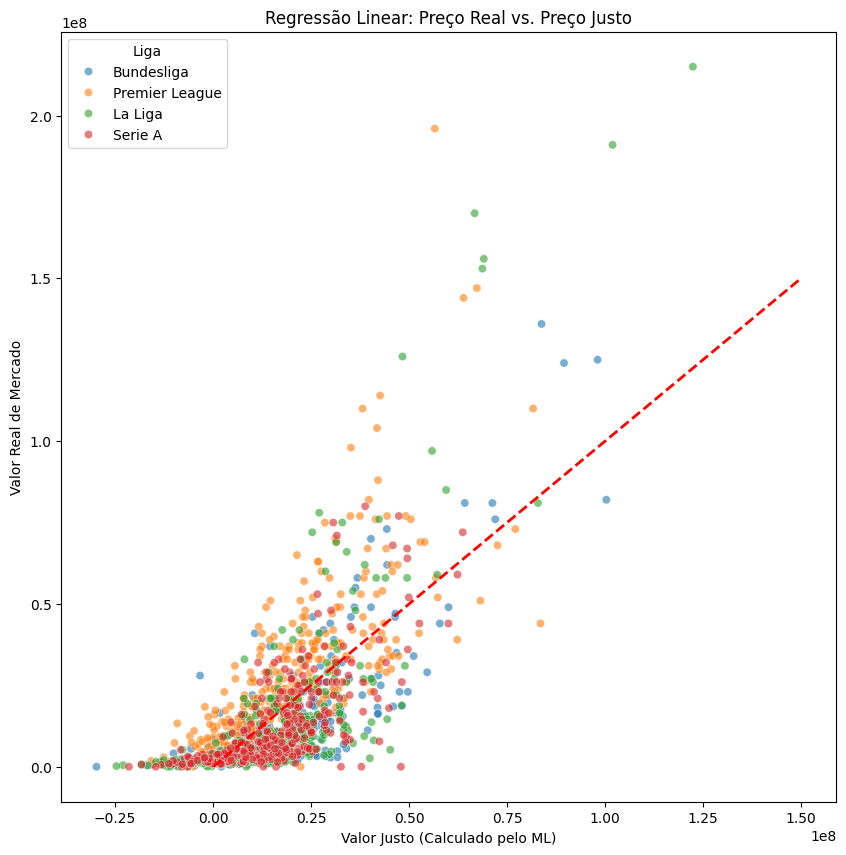

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import seaborn as sns

print("🤖 Iniciando treinamento do modelo de Valuation...")

# 1. Definir as Features (Variáveis que explicam o preço)
# Removemos linhas que tenham algum dado vazio nessas colunas para não dar erro
features = ['Idade_Limpa', 'Média das notas Sofascore', 'Gols', 'Assistências', 'Dribles certos']
target = 'Valor_Numerico'

# Cria um dataframe auxiliar apenas para o ML (sem dados vazios)
df_ml = df_geral.dropna(subset=features + [target]).copy()

X = df_ml[features] # O que o modelo usa para aprender
y = df_ml[target]   # O que o modelo tenta adivinhar

# 2. Treinar o Modelo
modelo = LinearRegression()
modelo.fit(X, y)

# 3. Fazer a Predição
df_ml['Valor_Predito'] = modelo.predict(X)

# 4. Calcular o Resíduo 
df_ml['Residuo'] = df_ml['Valor_Numerico'] - df_ml['Valor_Predito']

# 5. Métricas de Qualidade
r2 = r2_score(y, df_ml['Valor_Predito'])
print(f"✅ Modelo treinado com sucesso!")
print(f"📊 R² (Precisão do modelo): {r2:.2f} (Quanto mais perto de 1.0, melhor o modelo explica o preço)")

# --- ANÁLISE DOS RESULTADOS DO ML ---

# Top 5 Subvalorizados (Oportunidades Reais)
# Resíduo muito negativo = Preço Real é muito menor que o Predito
print("\n💎 ALVOS DE MERCADO (Jogadores Subvalorizados segundo a IA):")
print("O modelo diz que eles valem muito mais do que custam hoje.")
cols_show = ['Nome', 'Time', 'Liga', 'Valor_Numerico', 'Valor_Predito', 'Residuo']
display(df_ml.sort_values('Residuo').head(5)[cols_show])

# Top 5 Supervalorizados (Hype)
# Resíduo muito positivo = Preço Real é muito maior que o Predito
print("\n💸 CUIDADO (Jogadores Supervalorizados segundo a IA):")
print("O preço deles está inflacionado em relação ao que entregam em campo.")
display(df_ml.sort_values('Residuo', ascending=False).head(5)[cols_show])

# Ver o peso de cada variável
coeficientes = pd.DataFrame({'Variavel': features, 'Peso (€)': modelo.coef_})
pd.options.display.float_format = '{:,.2f}'.format
display(coeficientes)

# --- GRÁFICO: REAL vs JUSTO ---
plt.figure(figsize=(10, 10))
sns.scatterplot(x='Valor_Predito', y='Valor_Numerico', data=df_ml, hue='Liga', alpha=0.6)
plt.plot([0, 150000000], [0, 150000000], 'r--', lw=2) # Linha de tendência perfeita
plt.xlabel('Valor Justo (Calculado pelo ML)')
plt.ylabel('Valor Real de Mercado')
plt.title('Regressão Linear: Preço Real vs. Preço Justo')
plt.show()

In [9]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

print("🚀 Iniciando Valuation Avançado (Random Forest) com Gráficos Interativos...")

# 1. PREPARAÇÃO DOS DADOS
# Selecionamos colunas de jogo + contexto (Liga/Posição)
colunas_usadas = ['Idade_Limpa', 'Média das notas Sofascore', 'Gols', 'Assistências', 'Dribles certos', 'Posição', 'Liga']
target = 'Valor_Numerico'

df_ml = df_geral.dropna(subset=colunas_usadas + [target]).copy()

# One-Hot Encoding
X = pd.get_dummies(df_ml[colunas_usadas], columns=['Posição', 'Liga'], drop_first=True)
y = df_ml[target]

# 2. TREINAMENTO
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
modelo_rf.fit(X_train, y_train)

# 3. AVALIAÇÃO
r2 = r2_score(y_test, modelo_rf.predict(X_test))
print(f"✅ Modelo Treinado! Precisão (R²): {r2:.2f}")

# 4. CÁLCULO DO VALOR JUSTO E RESÍDUO
df_ml['Valor_Justo_RF'] = modelo_rf.predict(X)
df_ml['Residuo'] = df_ml['Valor_Numerico'] - df_ml['Valor_Justo_RF']

# Formatação para tabelas
pd.options.display.float_format = '{:,.0f}'.format

# --- TABELAS DE DESTAQUE ---
print("\n" + "="*60)
print("💸 TOP 5 SUPERVALORIZADOS (Preço Real >>> Preço Justo)")
display(df_ml.sort_values('Residuo', ascending=False).head(5)[['Nome', 'Time', 'Valor_Numerico', 'Valor_Justo_RF', 'Residuo']])

print("\n" + "="*60)
print("💎 TOP 5 SUBVALORIZADOS (Preço Real <<< Preço Justo)")
display(df_ml.sort_values('Residuo', ascending=True).head(5)[['Nome', 'Time', 'Valor_Numerico', 'Valor_Justo_RF', 'Residuo']])

# --- 5. GRÁFICO INTERATIVO (PLOTLY) ---
print("\n📊 GRÁFICO INTERATIVO: REAL vs JUSTO")
print("Passe o mouse para ver os nomes. A linha pontilhada vermelha é o 'Preço Perfeito'.")

# Criando o Scatter Plot
fig = px.scatter(df_ml, 
                 x='Valor_Justo_RF', 
                 y='Valor_Numerico', 
                 color='Liga',
                 hover_data=['Nome', 'Time', 'Idade_Limpa', 'Residuo'], 
                 opacity=0.6,
                 title='Valuation IA: Preço de Mercado (Y) vs Preço Justo Calculado (X)',
                 labels={
                     'Valor_Justo_RF': 'Preço Justo (IA) €', 
                     'Valor_Numerico': 'Preço Real de Mercado €'
                 })

# Adicionando a "Linha da Verdade" (x=y)
# Quem está SOBRE a linha: Preço Justo.
# Quem está MUITO ACIMA: Supervalorizado.
# Quem está MUITO ABAIXO: Subvalorizado.
max_val = df_ml['Valor_Numerico'].max()
fig.add_shape(type="line",
    x0=0, y0=0, x1=max_val, y1=max_val,
    line=dict(color="Red", width=2, dash="dash")
)

fig.show()

🚀 Iniciando Valuation Avançado (Random Forest) com Gráficos Interativos...
✅ Modelo Treinado! Precisão (R²): 0.76

💸 TOP 5 SUPERVALORIZADOS (Preço Real >>> Preço Justo)


,Nome,Time,Valor_Numerico,Valor_Justo_RF,Residuo
617,Lamine Yamal,Barcelona,"215,000,000","136,660,000","78,340,000"
618,Kylian Mbappé,Real Madrid,"191,000,000","123,082,000","67,918,000"
303,Bukayo Saka,Arsenal,"147,000,000","91,450,000","55,550,000"
327,Alexis Mac Allister,Liverpool,"110,000,000","70,658,000","39,342,000"
628,Vinícius Júnior,Real Madrid,"156,000,000","117,117,000","38,883,000"



💎 TOP 5 SUBVALORIZADOS (Preço Real <<< Preço Justo)


,Nome,Time,Valor_Numerico,Valor_Justo_RF,Residuo
626,Joan García,Barcelona,"26,000,000","64,502,000","-38,502,000"
963,Mateo Retegui,Al-Qadsiah,"44,000,000","78,680,000","-34,680,000"
974,Alexis Saelemaekers,Milan,"21,000,000","51,671,000","-30,671,000"
305,Amad Diallo,Manchester United,"39,000,000","66,000,000","-27,000,000"
621,Alejandro Baena,Atlético Madrid,"59,000,000","83,700,000","-24,700,000"



📊 GRÁFICO INTERATIVO: REAL vs JUSTO
Passe o mouse para ver os nomes. A linha pontilhada vermelha é o 'Preço Perfeito'.
